In [2]:
import json

import pandas as pd
import plotly.express as px

from utils.backtest import Portfolio, Timeline
from utils.data import jp_500
from utils.datetime import get_rebalance_date, get_quarter_end_date_string
from utils.datapath import (
    wins_signals_path,
    elo_signals_path,
    daily_prices_path
)
from utils.dummy import (
    generate_signals,
    sort_basket,
)

In [3]:
# Hack. Use a better solution to detect null columns and ignore or fix
null_columns = ['4385', '9147', '5831', '6526', '9434']

In [4]:
# Task 1:
# TODO: Get static historical Nikkei Constituents from Vinesh

# Nikkei 255 Constituents per quarter
constituents = {
    get_quarter_end_date_string(quarter): basket for quarter, basket in jp_500.items()
}

In [5]:
black_list = ["2372"]
price_df = pd.read_csv(daily_prices_path)
price_df = price_df.drop(columns=["Unnamed: 0"] + black_list).set_index("Date")


# How to handle nulls?
# price_df = price_df.ffill()
# price_df = price_df.bfill()

In [6]:
# Get all unique stocks that have been in Nikkei 225
# stock_list = list(set([stock for stocks in constituents.values() for stock in stocks]))
# prices = get_stock_prices(stock_list, start_date, end_date)
# price_df = pd.DataFrame(prices)


In [7]:
dummy_signal_series = generate_signals(constituents)

with open(elo_signals_path) as f:
    elo_signal_series = json.load(f)
    elo_signal_series = { get_rebalance_date(q_string): signal for q_string, signal in elo_signal_series.items() }
    

with open(wins_signals_path) as f:
    wins_signal_series = json.load(f)
    wins_signal_series = { get_rebalance_date(q_string): signal for q_string, signal in wins_signal_series.items() }

In [8]:
# Time to fix old simplifying actions

# 1. Downloading metadata and docs for all edinet codes, not just current Nikkei 225

In [9]:
signals = {
    "dummy": dummy_signal_series,
    "elo": elo_signal_series,
    "wins": wins_signal_series,
}

signal_series = signals["dummy"]

In [10]:
# TODO:
# Fix Backtests for JP 500

In [11]:
signal_series

{'2015-06-30': {'7203': 0.13880058469222967,
  '8306': 0.27176512139131626,
  '4502': 0.7064207582689094,
  '8316': 0.9897654487078944,
  '9432': 0.11921104743829503,
  '9983': 0.12435628833636081,
  '9433': 0.33760262932966056,
  '9984': 0.13883189600161072,
  '2914': 0.015118645424224919,
  '8411': 0.1947395186024602,
  '7267': 0.6076698394653002,
  '4755': 0.24047530461298516,
  '6758': 0.7946344215042918,
  '9022': 0.9165083728161637,
  '6861': 0.15847161553230216,
  '6954': 0.35879492537507507,
  '3382': 0.16012556697324687,
  '9020': 0.1194285997379485,
  '7201': 0.759197846314753,
  '6902': 0.3247287897834553,
  '4689': 0.1778168187615764,
  '6752': 0.4253937585216596,
  '6501': 0.483251598023165,
  '8802': 0.13471104103969256,
  '8801': 0.48273442032605063,
  '6503': 0.894259809574751,
  '7751': 0.8023695242215014,
  '6594': 0.5470217741466978,
  '4063': 0.6646263321201016,
  '8058': 0.09214752239084723,
  '4661': 0.2767661097760731,
  '7270': 0.8852393215540706,
  '8766': 0.84

In [12]:
def run_daily_backtest(
    price_df,
    signal_series,
    asset_count=20,
    shorting_enabled=False,
):
    # pre-sort baskets on signals
    sorted_basket_series = {
        date: sort_basket(signals) for date, signals in signal_series.items()
    }

    dates = list(price_df.index)

    initial_portfolio = Portfolio({}, {}, cash=1e4)
    timeline = Timeline(dates[0], initial_portfolio)

    for i, date in enumerate(dates, start=1):
        # compute daily returns
        ret = price_df.loc[date] / price_df.shift(1).loc[date] - 1
        timeline.remark(date, ret)

        # rebalance periodically
        if date in signal_series:
            # print(f"Rebalancing on {date}")
            sorted_basket = sorted_basket_series[date]

            top = sorted_basket[:asset_count]
            bottom = sorted_basket[-asset_count:] if shorting_enabled else []
            timeline.rebalance(date, top, bottom)

    return timeline

In [13]:
price_df

,6178,8316,8411,8306,9501,9432,8421,6758,4612,7203,...,4894,9330,5889,151A,135A,143A,9345,3045,5591,3350
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-06,NaN,1377.972534,1441.248047,464.625793,516.000000,38.969852,140142.765625,350.482147,316.761475,902.283691,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,407.423004,NaN,440.0
2014-01-07,NaN,1362.746582,1428.605225,458.530121,511.000000,38.690006,140142.765625,350.093170,313.041077,897.987183,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,411.835632,NaN,440.0
2014-01-08,NaN,1380.510376,1479.175781,468.689606,516.000000,39.809425,140437.015625,354.955566,313.041077,902.283691,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,411.835632,NaN,440.0
2014-01-09,NaN,1357.671021,1466.533325,461.239380,512.000000,39.319679,139774.906250,368.375763,314.635529,897.987183,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,411.835632,NaN,430.0
2014-01-10,NaN,1365.284302,1498.139648,464.625793,509.000000,39.599533,139848.484375,356.900482,318.001617,900.851624,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399.701233,NaN,440.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-23,1333.0,3617.000000,3894.000000,1942.500000,394.500000,150.800003,204000.000000,3683.000000,1057.500000,2623.500000,...,6090.0,781.0,2221.0,908.0,2226.0,837.0,2220.0,1375.000000,1634.0,816.0
2025-05-26,1331.5,3603.000000,3907.000000,1955.000000,396.500000,152.100006,204400.000000,3740.000000,1067.500000,2621.500000,...,6300.0,787.0,2208.0,920.0,2382.0,824.0,2220.0,1400.000000,1817.0,966.0
2025-05-27,1334.0,3621.000000,3959.000000,1977.000000,405.399994,151.399994,203500.000000,3809.000000,1064.000000,2640.000000,...,6290.0,780.0,2242.0,926.0,2480.0,821.0,2148.0,1400.000000,1776.0,1116.0


In [14]:
signal_series

{'2015-06-30': {'7203': 0.13880058469222967,
  '8306': 0.27176512139131626,
  '4502': 0.7064207582689094,
  '8316': 0.9897654487078944,
  '9432': 0.11921104743829503,
  '9983': 0.12435628833636081,
  '9433': 0.33760262932966056,
  '9984': 0.13883189600161072,
  '2914': 0.015118645424224919,
  '8411': 0.1947395186024602,
  '7267': 0.6076698394653002,
  '4755': 0.24047530461298516,
  '6758': 0.7946344215042918,
  '9022': 0.9165083728161637,
  '6861': 0.15847161553230216,
  '6954': 0.35879492537507507,
  '3382': 0.16012556697324687,
  '9020': 0.1194285997379485,
  '7201': 0.759197846314753,
  '6902': 0.3247287897834553,
  '4689': 0.1778168187615764,
  '6752': 0.4253937585216596,
  '6501': 0.483251598023165,
  '8802': 0.13471104103969256,
  '8801': 0.48273442032605063,
  '6503': 0.894259809574751,
  '7751': 0.8023695242215014,
  '6594': 0.5470217741466978,
  '4063': 0.6646263321201016,
  '8058': 0.09214752239084723,
  '4661': 0.2767661097760731,
  '7270': 0.8852393215540706,
  '8766': 0.84

In [15]:
timeline = run_daily_backtest(
    price_df, signal_series, asset_count=20, shorting_enabled=True
)

navs = timeline.get_navs()
print(f"Final NAV: {navs.iloc[-1]:.2f}")
print(f"Annualized Return: {timeline.calculate_annualized_return():.2%}")
print(f"Sharpe Ratio: {timeline.calculate_sharpe_ratio():.2f}")

Final NAV: 11997.13
Annualized Return: 1.65%
Sharpe Ratio: 0.02


<Axes: >

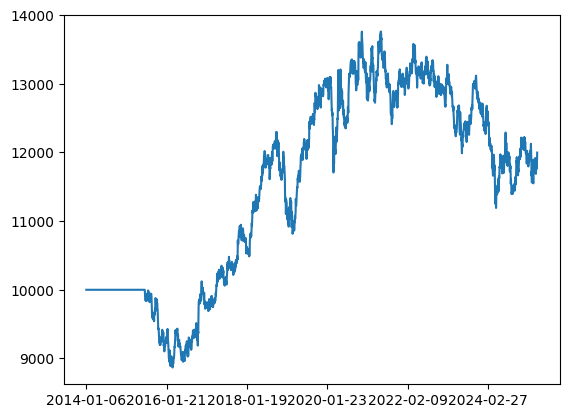

In [16]:
navs.plot()


In [ ]:
factor = "factor"
num_noise = 100

rebalance_days = 21
asset_count = 20

# container for all timelines
timelines = {}

# run the “factor” backtest
timelines[factor] = run_daily_backtest(
    price_df,
    signal_series,
    asset_count=asset_count,
    shorting_enabled=True,
)

# run N noise backtests
for i in range(num_noise):
    label = f"noise_{i}"
    timelines[label] = run_daily_backtest(
        price_df,
        generate_signals(constituents),
        asset_count=asset_count,
        shorting_enabled=True,
    )

In [ ]:
factor_cr = pd.Series(timelines[factor].get_cumulative_returns(), name=factor)

# noise series
noise_cr = [
    pd.Series(timelines[f"noise_{i}"].get_cumulative_returns(), name=f"noise_{i}")
    for i in range(num_noise)
]

df = pd.concat([factor_cr] + noise_cr, axis=1)

In [ ]:
fig = px.line(
    df,
    y=[col for col in df.columns if col.startswith("noise_")],
    labels={"value": "Cumulative Return", "index": "Date"},
)

# style the noise traces
for trace in fig.data:
    trace.update(line=dict(color="black", width=2, dash="dot"), opacity=0.1)

# overlay the factor line on top
fig.add_scatter(
    x=df.index,
    y=df[factor],
    mode="lines",
    name=factor,
    line=dict(color="red", width=4),
    marker=dict(size=7, color="red"),
)

fig.update_layout(
    width=1000,
    height=600,
    hovermode="closest",
    showlegend=False,
)

fig.show()

In [ ]:
print(f"Factor: {factor}")
print(f"Annualized Return: ", timelines[factor].calculate_annualized_return())
print(f"Sharpe Ratio:", timelines[factor].calculate_sharpe_ratio())

Factor: factor
Annualized Return:  -0.005529068512801216
Sharpe Ratio: -0.0019663951855823218


In [77]:
# Tasks to do:
# Make sense of the generated code - DONE
# Use the Nikkei 225 data instead - DONE
# Use the Nikkei 225 index instead - DONE


# Get Actual time series of prices
# Get Actual time series of signals # any
# Ask Vinesh for actual index constituents
# Use a valid signal like simple sentiment instead
# Use ELO score

In [ ]:
# TODO:

# 1. Proper baskets
# 2. Buggy backtests. Fail if you go back to 2010s. Will likely be fixed with proper baskets